In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [12]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV3/LSS/LSScats/test/LRGAlltiles_full.dat.fits'))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

129076
129076


In [13]:
mask = zbest['SV3_DESI_TARGET'] & 2**0 > 0
np.sum(mask)

129076

In [18]:
mask = zbest['TSNR2_LRG']<1e18
zbest = zbest[mask]
print(len(zbest))

119310


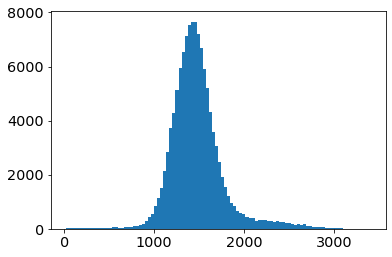

In [20]:
plt.hist(zbest['TSNR2_LRG']*13.5, 100)
plt.show()

In [29]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*zbest['Z']))
mask_remove = (d>30) & (zbest['DELTACHI2']<30)
mask_remove |= (d<30) & (zbest['DELTACHI2']<d)
mask_remove |= (zbest['DELTACHI2']<10)
mask_quality1 = zbest['ZWARN']==0
mask_quality1 &= zbest['Z']<1.4
mask_quality1 &= (~mask_remove)

In [30]:
def binned_frac(x, y, bin_edges, minsize=10):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            p1 = np.maximum(p, 1/n)  # error floor
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

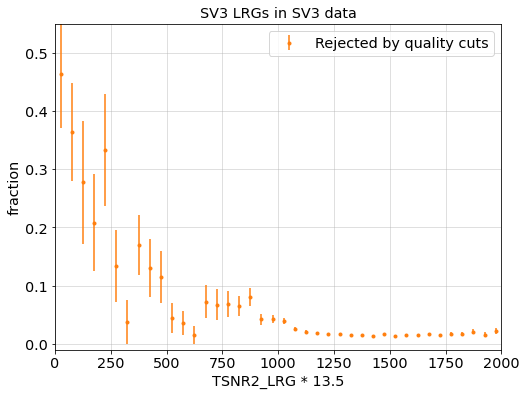

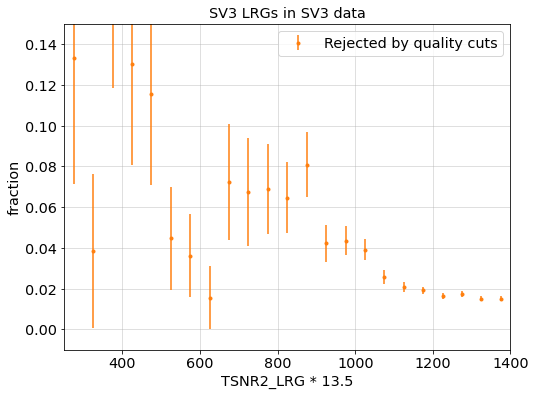

In [35]:
mask = np.full(len(zbest), True)
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(zbest['TSNR2_LRG'][mask] * 13.5, (~mask_quality1)[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cuts', color='C1')
plt.xlabel('TSNR2_LRG * 13.5')
plt.ylabel('fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV3 LRGs in SV3 data')
plt.axis([0, 2000, -0.01, 0.55])
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cuts', color='C1')
plt.xlabel('TSNR2_LRG * 13.5')
plt.ylabel('fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV3 LRGs in SV3 data')
plt.axis([250, 1400, -0.01, 0.15])
plt.show()

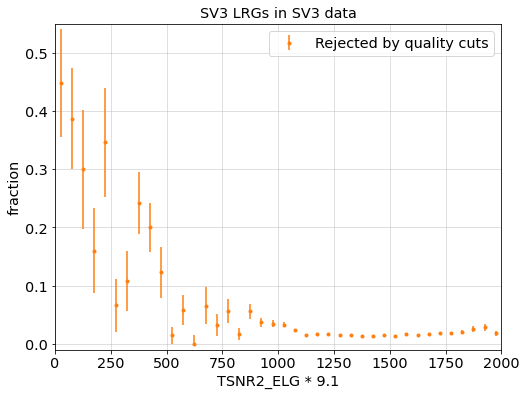

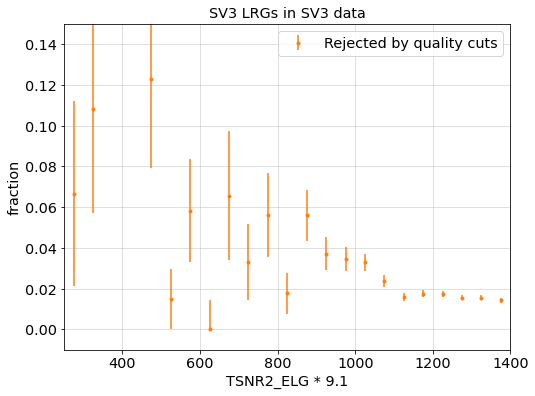

In [37]:
mask = np.full(len(zbest), True)
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(zbest['TSNR2_ELG'][mask] * 9.1, (~mask_quality1)[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cuts', color='C1')
plt.xlabel('TSNR2_ELG * 9.1')
plt.ylabel('fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV3 LRGs in SV3 data')
plt.axis([0, 2000, -0.01, 0.55])
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cuts', color='C1')
plt.xlabel('TSNR2_ELG * 9.1')
plt.ylabel('fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV3 LRGs in SV3 data')
plt.axis([250, 1400, -0.01, 0.15])
plt.show()